In [1]:
"""
Part 2 -- Benchmark forecasting models
======================================

Weekly German electricity demand (GW). Uses the weekly series produced in
Part 1. The test set is the last 104 weeks.

Design principles for this part
-------------------------------
1. FIXED FORECAST ORIGIN. All benchmarks are produced ONCE at the end of the
   training set and projected the full 104 weeks ahead. No benchmark is
   allowed to see any test observation -- this avoids the data leakage the
   README warns about (the starting pipeline's recursive seasonal-naive did
   leak, so it is deliberately NOT reproduced here).

2. Every model is scored on the SAME test window with MAE, RMSE, MASE and
   Bias. MASE is scaled by the in-sample seasonal-naive error, so the
   seasonal-naive model is the reference benchmark (MASE ~ 1 for it in-sample).
"""

"\nPart 2 -- Benchmark forecasting models\n======================================\n\nWeekly German electricity demand (GW). Uses the weekly series produced in\nPart 1. The test set is the last 104 weeks.\n\nDesign principles for this part\n-------------------------------\n1. FIXED FORECAST ORIGIN. All benchmarks are produced ONCE at the end of the\n   training set and projected the full 104 weeks ahead. No benchmark is\n   allowed to see any test observation -- this avoids the data leakage the\n   README warns about (the starting pipeline's recursive seasonal-naive did\n   leak, so it is deliberately NOT reproduced here).\n\n2. Every model is scored on the SAME test window with MAE, RMSE, MASE and\n   Bias. MASE is scaled by the in-sample seasonal-naive error, so the\n   seasonal-naive model is the reference benchmark (MASE ~ 1 for it in-sample).\n"

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

weekly = (
    pd.read_csv("data/processed/weekly_load.csv", index_col=0, parse_dates=True)
      .squeeze("columns")      # DataFrame -> Series
)
weekly = weekly.asfreq("W")    # restore the weekly frequency on the index

TEST_WEEKS = 104          # 2-year evaluation horizon
SEASONALITY = 52          # weeks per year

In [11]:
# ----------------------------------------------------------------------
# 1. Train / test split
# ----------------------------------------------------------------------

def train_test_split(weekly: pd.Series, test_weeks: int = TEST_WEEKS):
    """Chronological split -- never random for a time series."""
    train = weekly.iloc[:-test_weeks]
    test = weekly.iloc[-test_weeks:]
    return train, test

In [12]:
# ----------------------------------------------------------------------
# 2. Benchmark forecasters (fixed origin, no leakage)
# ----------------------------------------------------------------------

def mean_forecast(train: pd.Series, index: pd.DatetimeIndex) -> pd.Series:
    """Flat line at the training mean."""
    return pd.Series(train.mean(), index=index, name="mean")


def naive_forecast(train: pd.Series, index: pd.DatetimeIndex) -> pd.Series:
    """Flat line at the last observed training value."""
    return pd.Series(train.iloc[-1], index=index, name="naive")


def seasonal_naive_forecast(
    train: pd.Series, index: pd.DatetimeIndex, seasonality: int = SEASONALITY
) -> pd.Series:
    """
    Repeat the last observed full season. For horizon h:
        y_hat[T+h] = y[T + h - s * ceil(h / s)]
    which, for a fixed origin, is simply the last `s` training values tiled
    across the horizon. Uses ONLY training data.
    """
    horizon = len(index)
    last_season = train.iloc[-seasonality:].to_numpy()
    n_tiles = int(np.ceil(horizon / seasonality))
    values = np.tile(last_season, n_tiles)[:horizon]
    return pd.Series(values, index=index, name="seasonal_naive")


def drift_forecast(train: pd.Series, index: pd.DatetimeIndex) -> pd.Series:
    """
    Extrapolate the straight line through the first and last training points.
        slope = (y_T - y_1) / (T - 1)
        y_hat[T+h] = y_T + slope * h
    """
    horizon = len(index)
    slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
    values = train.iloc[-1] + slope * np.arange(1, horizon + 1)
    return pd.Series(values, index=index, name="drift")


def all_benchmarks(train: pd.Series, test: pd.Series) -> dict[str, pd.Series]:
    idx = test.index
    return {
        "mean": mean_forecast(train, idx),
        "naive": naive_forecast(train, idx),
        "seasonal_naive": seasonal_naive_forecast(train, idx),
        "drift": drift_forecast(train, idx),
    }

In [13]:
# ----------------------------------------------------------------------
# 3. Optional: seasonal-naive prediction interval
# ----------------------------------------------------------------------

def seasonal_naive_intervals(
    train: pd.Series, index: pd.DatetimeIndex,
    seasonality: int = SEASONALITY, z: float = 1.96,
) -> pd.DataFrame:
    """
    Analytic prediction interval for the seasonal-naive forecast.
    The h-step-ahead standard error grows with the number of seasonal cycles
    ahead:  sigma_h = sigma * sqrt(k),  k = floor((h-1)/s) + 1,
    where sigma is the in-sample one-season-ahead residual std.
    Useful for the 'prediction interval coverage' diagnostic in the README.
    """
    resid = train.to_numpy()[seasonality:] - train.to_numpy()[:-seasonality]
    sigma = np.std(resid, ddof=1)

    point = seasonal_naive_forecast(train, index, seasonality).to_numpy()
    h = np.arange(1, len(index) + 1)
    k = np.floor((h - 1) / seasonality) + 1
    se = sigma * np.sqrt(k)

    return pd.DataFrame(
        {"lower": point - z * se, "upper": point + z * se}, index=index
    )

In [14]:
# ----------------------------------------------------------------------
# 4. Evaluation metrics
# ----------------------------------------------------------------------

def _mase(y_true, y_pred, y_train, seasonality: int = SEASONALITY) -> float:
    """MASE scaled by in-sample seasonal-naive mean absolute error."""
    yt = y_train.to_numpy()
    scale = np.mean(np.abs(yt[seasonality:] - yt[:-seasonality]))
    return np.mean(np.abs(y_true.to_numpy() - y_pred.to_numpy())) / scale


def evaluate_forecast(name, y_true, y_pred, y_train) -> dict:
    y_pred = y_pred.reindex(y_true.index)
    err = y_pred.to_numpy() - y_true.to_numpy()
    return {
        "model": name,
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MASE": float(_mase(y_true, y_pred, y_train)),
        "Bias": float(np.mean(err)),
    }


def evaluate_all(forecasts: dict, test: pd.Series, train: pd.Series) -> pd.DataFrame:
    rows = [evaluate_forecast(n, test, p, train) for n, p in forecasts.items()]
    return pd.DataFrame(rows).sort_values("MASE").reset_index(drop=True)

In [15]:
# ----------------------------------------------------------------------
# 5. Plotting
# ----------------------------------------------------------------------

def plot_benchmarks(
    train: pd.Series, test: pd.Series, forecasts: dict,
    intervals: pd.DataFrame | None = None, path=None,
):
    """Full history + 2-year test window with every benchmark overlaid."""
    fig, ax = plt.subplots(figsize=(13, 6))

    ax.plot(train.index, train, color="tab:gray", lw=1, label="Train")
    ax.plot(test.index, test, color="black", lw=2, label="Test (actual)")

    styles = {
        "mean": ("tab:purple", "--"),
        "naive": ("tab:orange", "--"),
        "seasonal_naive": ("tab:green", "-"),
        "drift": ("tab:red", "--"),
    }
    for name, pred in forecasts.items():
        c, ls = styles.get(name, ("tab:blue", "-"))
        ax.plot(pred.index, pred, color=c, ls=ls, lw=1.6, label=name)

    if intervals is not None:
        ax.fill_between(
            intervals.index, intervals["lower"], intervals["upper"],
            color="tab:green", alpha=0.12, label="seasonal_naive 95% PI",
        )

    ax.axvline(test.index[0], color="k", lw=0.8, alpha=0.4)
    ax.set_title("Benchmark forecasts -- weekly German load, 2-year horizon")
    ax.set_ylabel("Load (GW)")
    ax.set_xlabel("Date")
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

In [16]:
# ----------------------------------------------------------------------
# Orchestration
# ----------------------------------------------------------------------

def run_part2(weekly: pd.Series, test_weeks: int = TEST_WEEKS,
              save_dir: str | None = None):
    import os

    train, test = train_test_split(weekly, test_weeks)
    print(f"Train: {train.index.min().date()} .. {train.index.max().date()} "
          f"({len(train)} wks)")
    print(f"Test:  {test.index.min().date()} .. {test.index.max().date()} "
          f"({len(test)} wks)\n")

    forecasts = all_benchmarks(train, test)
    intervals = seasonal_naive_intervals(train, test.index)
    metrics = evaluate_all(forecasts, test, train)

    print("Benchmark accuracy (sorted by MASE):")
    print(metrics.round(3).to_string(index=False))

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        metrics.to_csv(os.path.join(save_dir, "benchmark_metrics.csv"), index=False)
        fc_df = pd.DataFrame({"actual": test})
        for n, p in forecasts.items():
            fc_df[n] = p
        fc_df.to_csv(os.path.join(save_dir, "benchmark_forecasts.csv"))

    plot_path = os.path.join(save_dir, "benchmark_forecasts.png") if save_dir else None
    plot_benchmarks(train, test, forecasts, intervals, path=plot_path)

    return forecasts, metrics

Train: 2015-01-04 .. 2018-10-07 (197 wks)
Test:  2018-10-14 .. 2020-10-04 (104 wks)

Benchmark accuracy (sorted by MASE):
         model   MAE  RMSE  MASE   Bias
seasonal_naive 2.319 3.007 1.732  1.732
         naive 3.783 4.459 2.827 -0.882
          mean 3.789 4.397 2.831  0.481
         drift 4.340 5.118 3.243  1.007


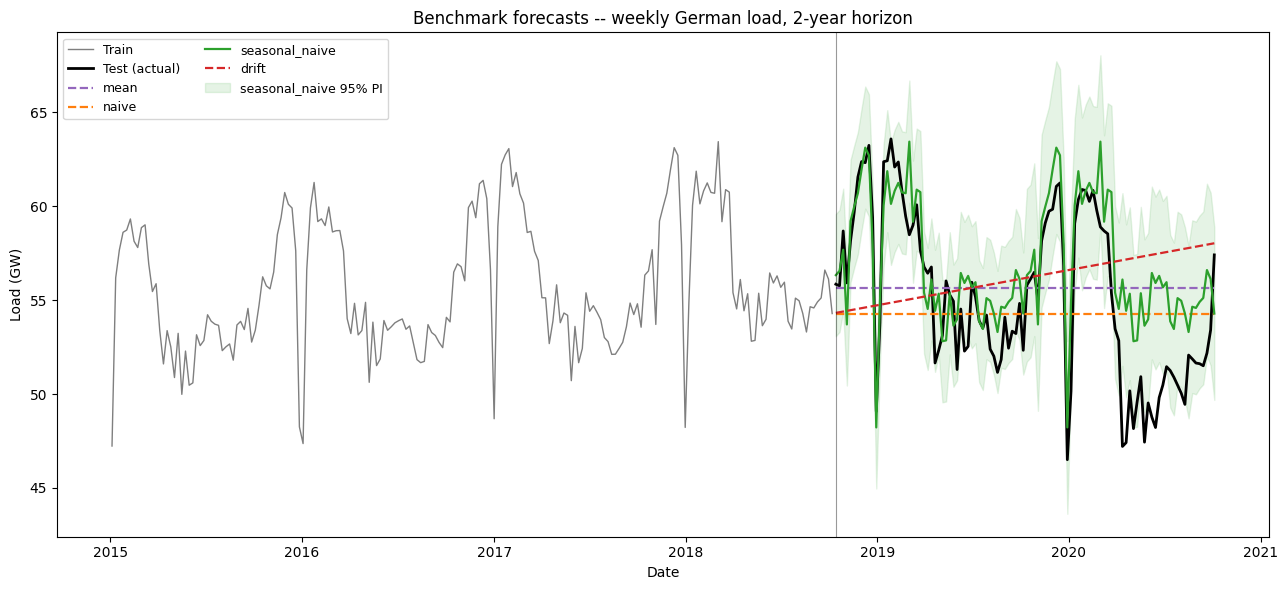

In [ ]:
forecasts, metrics = run_part2(weekly, test_weeks=104, save_dir="outputs/02")